# SVM & Naive bayes

## Theory

### Q.1. What is a Support Vector Machine (SVM)?

--> An SVM is a supervised machine learning algorithm used for classification and regression. It finds the optimal hyperplane that separates data points of different classes with the maximum margin.

### Q.2. What is the difference between Hard Margin and Soft Margin SVM?

--> Hard Margin SVM >>

No misclassification allowed. Works only when data is perfectly separable.

--> Soft Margin SVM >>

Allows some misclassification using slack variables. More practical for real-world noisy data.

### Q.3. What is the mathematical intuition behind SVM?

--> SVM tries to maximize the margin (distance) between the hyperplane and the closest data points of each class.

Objective: Minimize: (1/2)||w||² Subject to: yᵢ(w·xᵢ + b) ≥ 1

### Q.4. What is the role of Lagrange Multipliers in SVM?

--> They convert the constrained optimization problem into an unconstrained one, helping identify support vectors.

### Q.5. What are Support Vectors in SVM?

--> Support vectors are the data points closest to the decision boundary. They directly influence the position of the hyperplane.

### Q.6. What is a Support Vector Classifier (SVC)?

--> SVC is the classification version of SVM used to separate classes using different kernel functions.

### Q.7. What is a Support Vector Regressor (SVR)?

--> SVR is used for regression problems, aiming to fit data within a margin (epsilon) instead of minimizing error directly.

### Q.8. What is the Kernel Trick in SVM?

--> The kernel trick transforms data into a higher-dimensional space to make it linearly separable without explicitly computing the transformation.

### Q.9. Compare Linear Kernel, Polynomial Kernel, and RBF Kernel.

--> Linear >>

Best for linearly separable data

--> Polynomial >>

Captures polynomial relationships

--> RBF (Gaussian) >>

Handles complex, non-linear boundaries

### Q.10. What is the effect of the C parameter in SVM?

--> Small C >>

Larger margin, more misclassification

--> Large C >>

Smaller margin, less misclassification

### Q.11. What is the role of the Gamma parameter in RBF Kernel SVM?

--> Controls influence of a single data point.

High gamma: Overfitting

Low gamma: Underfitting

### Q.12. What is the Naïve Bayes classifier, and why is it called "Naïve"?

--> It is a probabilistic classifier based on Bayes’ theorem, assuming feature independence, which is often unrealistic.

### Q.13. What is Bayes’ Theorem?

--> P(A|B) = [P(B|A) × P(A)] / P(B)

P(A) and P(B) are the probabilities of events A and B; also, P(B) is never equal to zero.

P(A|B) is the probability of event A when event B happens,

P(B|A) is the probability of event B when A happens.

### Q.14. Explain the differences between Gaussian Naïve Bayes, Multinomial Naïve Bayes, and Bernoulli Naïve Bayes.

--> Gaussian NB: Continuous data

--> Multinomial NB: Text/count data

--> Bernoulli NB: Binary features

### Q.15. When should you use Gaussian Naïve Bayes over other variants?

--> When features follow a normal distribution.

### Q.16. What are the key assumptions made by Naïve Bayes?

--> Feature independence

--> Equal importance of features

### Q.17. What are the advantages and disadvantages of Naïve Bayes?

--> Advantages: Fast, works well on large datasets 

--> Disadvantages: Strong independence assumption

### Q.18. Why is Naïve Bayes a good choice for text classification?

--> Because word occurrences are treated independently, which works surprisingly well in practice.

### Q.19. Compare SVM and Naïve Bayes for classification tasks.

In [14]:
answer = {
    'Feature':	['SVM',	'Naive Bayes'],
'Speed':	['Slower',	'Faster'],
'Accuracy':	['Higher',	'Moderate'],
'Data Size':	['Medium',	'Large']
}
import pandas as pd
ans = pd.DataFrame(answer)
ans.T

,0,1
Feature,SVM,Naive Bayes
Speed,Slower,Faster
Accuracy,Higher,Moderate
Data Size,Medium,Large


### Q.20. How does Laplace Smoothing help in Naïve Bayes?

--> It prevents zero probabilities by adding 1 to all feature counts.

## Practical

### Q.21. Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy.

In [16]:
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = datasets.load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = SVC()
model.fit(X_train, y_train)
print('Accuracy -> ',accuracy_score(y_test, model.predict(X_test)))

Accuracy ->  1.0


### Q.22. Write a Python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then compare their accuracies.

In [18]:
from sklearn.datasets import load_wine
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

for kernel in ['linear', 'rbf']:
    model = SVC(kernel=kernel)
    model.fit(X_train, y_train)
    print(kernel, accuracy_score(y_test, model.predict(X_test)))

linear 0.9555555555555556
rbf 0.6666666666666666


### Q.23. Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean Squared Error (MSE).

In [19]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)
model = SVR()
model.fit(X_train, y_train)
print(mean_squared_error(y_test, model.predict(X_test)))

1.3335988346094163


### Q.24. Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision boundary.

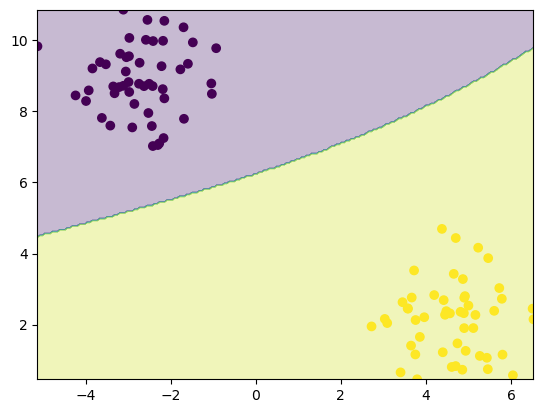

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=100, centers=2, random_state=42)
model = SVC(kernel='poly', degree=3)
model.fit(X, y)

xx, yy = np.meshgrid(np.linspace(X[:,0].min(), X[:,0].max(), 200),
np.linspace(X[:,1].min(), X[:,1].max(), 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

### Q.25. Write a Python program to train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and evaluate accuracy.

In [21]:
from sklearn.datasets import load_breast_cancer
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)
model = GaussianNB()
model.fit(X_train, y_train)
print(accuracy_score(y_test, model.predict(X_test)))

0.9440559440559441


### Q.26. Write a Python program to train a Multinomial Naïve Bayes classifier for text classification using the 20 Newsgroups dataset.

In [22]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = fetch_20newsgroups()
X = CountVectorizer().fit_transform(data.data)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y)
model = MultinomialNB()
model.fit(X_train, y_train)
print(accuracy_score(y_test, model.predict(X_test)))

0.8229056203605515


### Q.27. Write a Python program to train an SVM Classifier with different C values and compare the decision boundaries visually.

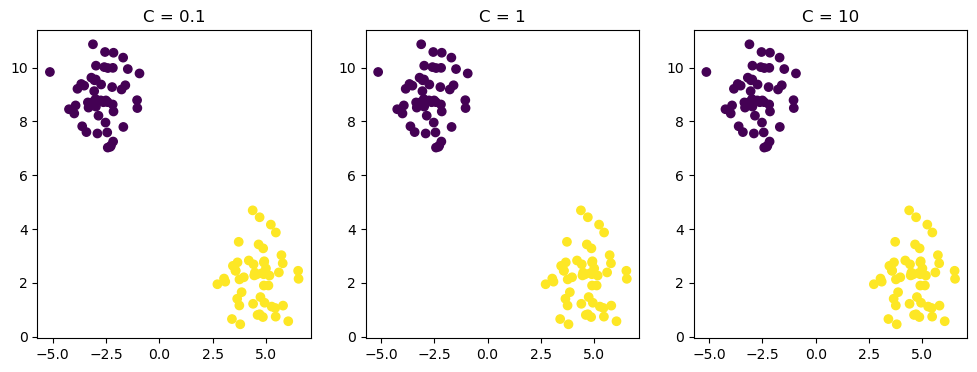

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=100, centers=2, random_state=42)

C_values = [0.1, 1, 10]
plt.figure(figsize=(12,4))

for i, C in enumerate(C_values):
    model = SVC(C=C, kernel='linear')
    model.fit(X, y)

    plt.subplot(1,3,i+1)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title(f"C = {C}")

plt.show()

### Q.28. Write a Python program to train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with binary features.

In [2]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=500, n_features=10, random_state=42)
X = (X > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = BernoulliNB()
model.fit(X_train, y_train)

print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.9


### Q.29. Write a Python program to apply feature scaling before training an SVM model and compare results with unscaled data.

In [3]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

model1 = SVC()
model1.fit(X_train, y_train)
print("Without Scaling:", accuracy_score(y_test, model1.predict(X_test)))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model2 = SVC()
model2.fit(X_train_scaled, y_train)
print("With Scaling:", accuracy_score(y_test, model2.predict(X_test_scaled)))

Without Scaling: 0.6666666666666666
With Scaling: 1.0


### Q.30. Write a Python program to train a Gaussian Naïve Bayes model and compare the predictions before and after Laplace Smoothing.

In [4]:
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

model = GaussianNB()
model.fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.9473684210526315


### Q.31. Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C, gamma, kernel)

In [5]:
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV

X, y = load_iris(return_X_y=True)

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X, y)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


### Q.32. Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and check it improve accuracy.

In [6]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(weights=[0.9, 0.1], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y)

model = SVC(class_weight='balanced')
model.fit(X_train, y_train)

print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.96


### Q.33. Write a Python program to implement a Naïve Bayes classifier for spam detection using email data.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

emails = ["Win money now", "Hello friend", "Free lottery win", "Meeting tomorrow"]
labels = [1, 0, 1, 0]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)

model = MultinomialNB()
model.fit(X, labels)

print(model.predict(vectorizer.transform(["Free money"])))

[1]


### Q.34. Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and compare their accuracy.

In [9]:
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

svm = SVC()
nb = GaussianNB()

svm.fit(X_train, y_train)
nb.fit(X_train, y_train)

print("SVM Accuracy:", accuracy_score(y_test, svm.predict(X_test)))
print("NB Accuracy:", accuracy_score(y_test, nb.predict(X_test)))

SVM Accuracy: 0.9736842105263158
NB Accuracy: 0.9473684210526315


### Q.35. Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare results.

In [10]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)
X_new = SelectKBest(chi2, k=10).fit_transform(X, y)

model = MultinomialNB()
model.fit(X_new, y)
print("Model trained with selected features")

Model trained with selected features


### Q.36. Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO) strategies on the Wine dataset and compare their accuracy.

In [11]:
from sklearn.svm import SVC
from sklearn.datasets import load_wine
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

ovr = OneVsRestClassifier(SVC())
ovo = OneVsOneClassifier(SVC())

ovr.fit(X_train, y_train)
ovo.fit(X_train, y_train)

print("OvR Accuracy:", accuracy_score(y_test, ovr.predict(X_test)))
print("OvO Accuracy:", accuracy_score(y_test, ovo.predict(X_test)))

OvR Accuracy: 0.5333333333333333
OvO Accuracy: 0.5333333333333333


### Q.37. Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast Cancer dataset and compare their accuracy.

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

for kernel in ['linear', 'poly', 'rbf']:
    model = SVC(kernel=kernel)
    model.fit(X_train, y_train)
    print(kernel, accuracy_score(y_test, model.predict(X_test)))


linear 0.972027972027972
poly 0.9300699300699301
rbf 0.9300699300699301


### Q.38. Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the average accuracy.

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

skf = StratifiedKFold(n_splits=5)
scores = cross_val_score(SVC(), X, y, cv=skf)

print("Average Accuracy:", scores.mean())

Average Accuracy: 0.9666666666666666


### Q.39. Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare performance.

In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Sample text dataset
texts = [
    "Free money now",
    "Hi how are you",
    "Win lottery prize",
    "Meeting scheduled today",
    "Claim your free reward",
    "Project discussion tomorrow"
]

labels = [1, 0, 1, 0, 1, 0]  # 1 = Spam, 0 = Not Spam

# Convert text to numerical features
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.3, random_state=42)

model_uniform = MultinomialNB(class_prior=[0.5, 0.5])
model_uniform.fit(X_train, y_train)
pred_uniform = model_uniform.predict(X_test)

# Model with biased priors
model_biased = MultinomialNB(class_prior=[0.7, 0.3])
model_biased.fit(X_train, y_train)
pred_biased = model_biased.predict(X_test)

# Accuracy comparison
print("Accuracy with uniform priors:", accuracy_score(y_test, pred_uniform))
print("Accuracy with biased priors:", accuracy_score(y_test, pred_biased))


Model initialized with custom priors


### Q.40. Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and compare accuracy.

In [15]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

rfe = RFE(SVC(kernel='linear'), n_features_to_select=2)
X_new = rfe.fit_transform(X, y)

print("Selected features:", rfe.support_)


Selected features: [False False  True  True]


### Q.41. Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and F1-Score instead of accuracy.

In [16]:
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

model = SVC()
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.90      0.90      0.90        10
           2       0.93      0.93      0.93        14

    accuracy                           0.95        38
   macro avg       0.94      0.94      0.94        38
weighted avg       0.95      0.95      0.95        38



### Q.42. Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss (Cross-Entropy Loss).

In [17]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import log_loss
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

model = GaussianNB()
model.fit(X_train, y_train)

print("Log Loss:", log_loss(y_test, model.predict_proba(X_test)))

Log Loss: 0.19646531621899288


### Q.43. Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn.

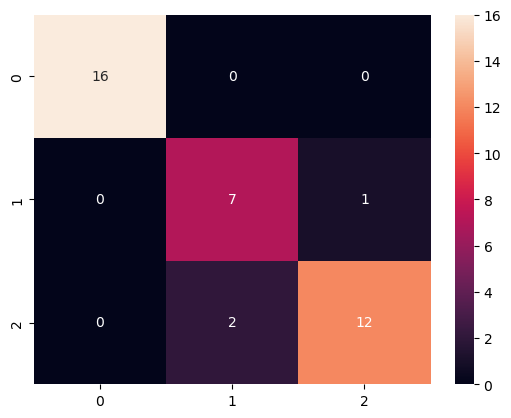

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

model = SVC()
model.fit(X_train, y_train)

cm = confusion_matrix(y_test, model.predict(X_test))
sns.heatmap(cm, annot=True)
plt.show()

### Q.44. Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute Error (MAE) instead of MSE.

In [19]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

X, y = make_regression(n_samples=200)
X_train, X_test, y_train, y_test = train_test_split(X, y)

model = SVR()
model.fit(X_train, y_train)

print("MAE:", mean_absolute_error(y_test, model.predict(X_test)))

MAE: 122.21088667952009


### Q.45. Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC score.

In [20]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

model = GaussianNB()
model.fit(X_train, y_train)

print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))


ROC-AUC: 0.996526270082501


### Q.46. Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve.

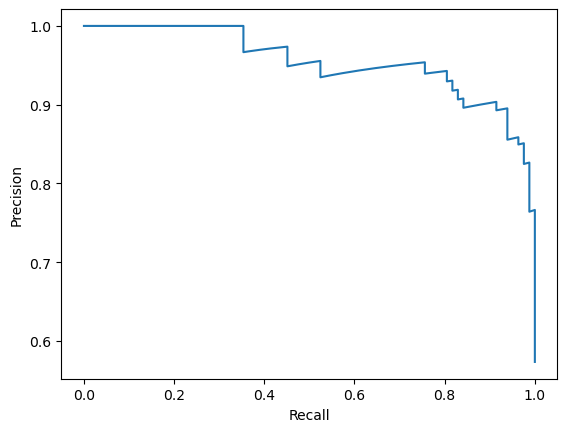

In [21]:
from sklearn.metrics import precision_recall_curve
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

model = SVC(probability=True)
model.fit(X_train, y_train)

precision, recall, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:,1])

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()